# SVM Assignment Solutions

In [ ]:
pip install ucimlrepo

TASK-1: [1 marks]

1.1. Load the combined cycle power plant dataset from UCI. [0.5 marks]

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
combined_cycle_power_plant = fetch_ucirepo(id=294)

# data (as pandas dataframes)
X = combined_cycle_power_plant.data.features
y = combined_cycle_power_plant.data.targets

# metadata
# print(combined_cycle_power_plant.metadata)

# variable information
print(combined_cycle_power_plant.variables)

  name     role        type demographic                          description  \
0   AT  Feature  Continuous        None      in the range 1.81°C and 37.11°C   
1    V  Feature  Continuous        None       in teh range 25.36-81.56 cm Hg   
2   AP  Feature  Continuous        None  in the range 992.89-1033.30 milibar   
3   RH  Feature  Continuous        None       in the range 25.56% to 100.16%   
4   PE   Target  Continuous        None                     420.26-495.76 MW   

     units missing_values  
0        C             no  
1    cm Hg             no  
2  milibar             no  
3        %             no  
4       MW             no  


1.2. Split the dataset into training, validation and test sets (70%-15%-15%). [0.5 marks]

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (70%), validation (15%), and test (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Flatten y
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()
y_test = y_test.values.ravel()

TASK-2: [2 marks]

2.1. Perform feature scaling such that the features lie in the same range of values. [1 marks]

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training set and transform all splits
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling done.")

Feature scaling done.


2.2. Show the correlation between the features of the training set. [1 marks]

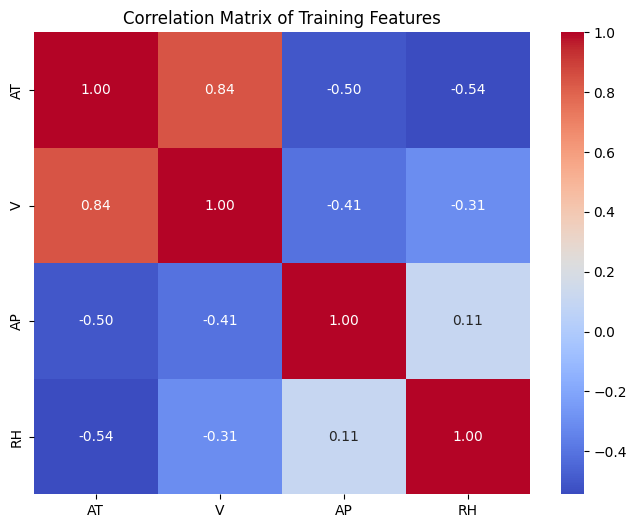

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert scaled train set back to dataframe with original column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Compute correlation
corr_matrix = X_train_scaled_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Training Features")
plt.show()

TASK-3: [5 marks]

3.1. Fit an SVM with linear kernel on the training set using sklearn’s SVR. [2 marks]

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Fit SVM with linear kernel
svm_linear = SVR(kernel='linear')
svm_linear.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = svm_linear.predict(X_train)
y_val_pred = svm_linear.predict(X_val)

# Evaluation metrics
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("SVR with Linear Kernel Results:")
print(f"Training MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}, R²: {val_r2:.4f}")

SVR with Linear Kernel Results:
Training MSE: 20.6777, R²: 0.9288
Validation MSE: 21.0616, R²: 0.9293


3.2. Tune the hyperparameters C and ε on the validation set using grid search (Take range of values of C and ε as provided below). [3 marks]

C = 0.01, 0.1, 1, 10, 100; ε = 0.001, 0.01, 0.1, 0.5, 1.0

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define parameter grid
C_values = [0.01, 0.1, 1, 10, 100]
epsilon_values = [0.001, 0.01, 0.1, 0.5, 1.0]

best_score = float('inf')  # we minimize MSE
best_params = {}

for C in C_values:
    for epsilon in epsilon_values:
        # Train SVR with linear kernel
        model = SVR(kernel='linear', C=C, epsilon=epsilon)
        model.fit(X_train, y_train)

        # Validate
        y_val_pred = model.predict(X_val)
        mse = mean_squared_error(y_val, y_val_pred)
        r2 = r2_score(y_val, y_val_pred)

        print(f"C={C}, epsilon={epsilon} --> MSE={mse:.4f}, R^2={r2:.4f}")

        # Keep best
        if mse < best_score:
            best_score = mse
            best_params = {"C": C, "epsilon": epsilon, "MSE": mse, "R2": r2}

print("\nBest parameters (on validation set):", best_params)

C=0.01, epsilon=0.001 --> MSE=21.1904, R^2=0.9288
C=0.01, epsilon=0.01 --> MSE=21.1887, R^2=0.9288
C=0.01, epsilon=0.1 --> MSE=21.1772, R^2=0.9289
C=0.01, epsilon=0.5 --> MSE=21.1968, R^2=0.9288
C=0.01, epsilon=1.0 --> MSE=21.1599, R^2=0.9289
C=0.1, epsilon=0.001 --> MSE=21.2388, R^2=0.9287
C=0.1, epsilon=0.01 --> MSE=21.2488, R^2=0.9286
C=0.1, epsilon=0.1 --> MSE=21.2499, R^2=0.9286
C=0.1, epsilon=0.5 --> MSE=21.2169, R^2=0.9287
C=0.1, epsilon=1.0 --> MSE=21.1904, R^2=0.9288
C=1, epsilon=0.001 --> MSE=21.1843, R^2=0.9288
C=1, epsilon=0.01 --> MSE=21.1505, R^2=0.9290
C=1, epsilon=0.1 --> MSE=21.0616, R^2=0.9293
C=1, epsilon=0.5 --> MSE=21.1822, R^2=0.9289
C=1, epsilon=1.0 --> MSE=21.1393, R^2=0.9290
C=10, epsilon=0.001 --> MSE=21.3183, R^2=0.9284
C=10, epsilon=0.01 --> MSE=21.2371, R^2=0.9287
C=10, epsilon=0.1 --> MSE=21.2078, R^2=0.9288
C=10, epsilon=0.5 --> MSE=21.2463, R^2=0.9286
C=10, epsilon=1.0 --> MSE=22.1872, R^2=0.9255
C=100, epsilon=0.001 --> MSE=55.9252, R^2=0.8122
C=100, ep

TASK-4: [3 marks]

4.1. Evaluate the linear SVM regressor using the best value of C and ε you obtained. Report the performance in terms of MSE and R^2 score. [1 marks]

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR

# Train model with best C and ε found from grid search
best_C = best_params['C']
best_epsilon = best_params['epsilon']

best_model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
best_model.fit(X_train, y_train)

# Evaluate on test set
y_test_pred = best_model.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Best Linear SVR Performance on Test Set:")
print(f"  Test MSE: {mse_test:.4f}")
print(f"  Test R²: {r2_test:.4f}")

Best Linear SVR Performance on Test Set:
  Test MSE: 21.9115
  Test R²: 0.9240


4.2. Show a scatter plot of the predictions of the linear SVR model vs. the ground truth target values. [2 marks]

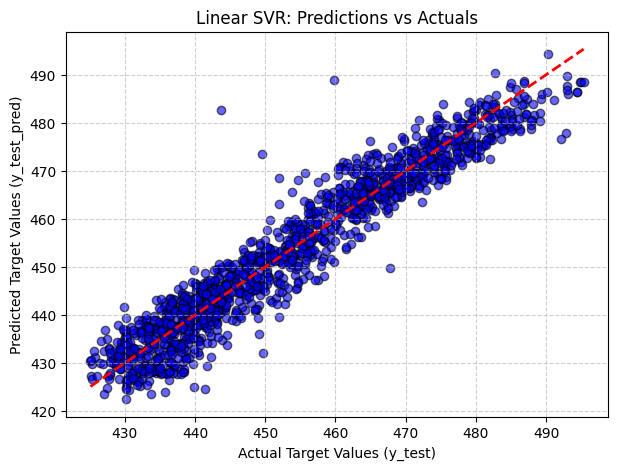

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot: predicted vs. actual
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.6, edgecolors='k')

# Add diagonal line (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("Actual Target Values (y_test)")
plt.ylabel("Predicted Target Values (y_test_pred)")
plt.title("Linear SVR: Predictions vs Actuals")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

TASK-5: [6 marks]

5.1. Fit an SVM with RBF kernel on the training set using sklearn’s SVR. [2 marks]

In [ ]:
# Fit SVM with RBF kernel
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = svr_rbf.predict(X_train)
y_val_pred = svr_rbf.predict(X_val)

# Evaluation metrics
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("SVR with RBF Kernel Results:")
print(f"Training MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}, R²: {val_r2:.4f}")

SVR with RBF Kernel Results:
Training MSE: 191.0983, R²: 0.3420
Validation MSE: 195.4755, R²: 0.3435


5.2. Tune the hyperparameters C, γ and ε on the validation set using grid search (Take range of values of C, γ and ε as provided below). [4 marks]

C = 0.1, 1, 10, 100, 1000; γ = 0.001, 0.01, 0.1, 1, 10; ε = 0.01, 0.1, 0.5, 1.0

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Define parameter grid for RBF kernel
C_values = [0.1, 1, 10, 100, 1000]
epsilon_values = [0.01, 0.1, 0.5, 1.0]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

best_score = float('inf')   # we want to minimize MSE
best_params = {}

for C in C_values:
    for epsilon in epsilon_values:
        for gamma in gamma_values:
            # Train SVR with RBF kernel
            model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
            model.fit(X_train, y_train)

            # Validate on validation set
            y_val_pred = model.predict(X_val)
            mse = mean_squared_error(y_val, y_val_pred)
            r2 = r2_score(y_val, y_val_pred)

            print(f"C={C}, epsilon={epsilon}, gamma={gamma} --> MSE={mse:.4f}, R^2={r2:.4f}")

            # Keep track of best parameters
            if mse < best_score:
                best_score = mse
                best_params = {"C": C, "epsilon": epsilon, "gamma": gamma, "MSE": mse, "R2": r2}

print("\nBest parameters (on validation set):", best_params)

C=0.1, epsilon=0.01, gamma=0.001 --> MSE=26.1378, R^2=0.9122
C=0.1, epsilon=0.01, gamma=0.01 --> MSE=42.1495, R^2=0.8584
C=0.1, epsilon=0.01, gamma=0.1 --> MSE=247.0953, R^2=0.1701
C=0.1, epsilon=0.01, gamma=1 --> MSE=304.9615, R^2=-0.0243
C=0.1, epsilon=0.01, gamma=10 --> MSE=307.1238, R^2=-0.0315
C=0.1, epsilon=0.1, gamma=0.001 --> MSE=26.1489, R^2=0.9122
C=0.1, epsilon=0.1, gamma=0.01 --> MSE=42.0529, R^2=0.8588
C=0.1, epsilon=0.1, gamma=0.1 --> MSE=247.0779, R^2=0.1701
C=0.1, epsilon=0.1, gamma=1 --> MSE=305.0121, R^2=-0.0244
C=0.1, epsilon=0.1, gamma=10 --> MSE=307.0968, R^2=-0.0314
C=0.1, epsilon=0.5, gamma=0.001 --> MSE=26.0884, R^2=0.9124
C=0.1, epsilon=0.5, gamma=0.01 --> MSE=42.2298, R^2=0.8582
C=0.1, epsilon=0.5, gamma=0.1 --> MSE=246.9880, R^2=0.1704
C=0.1, epsilon=0.5, gamma=1 --> MSE=305.2232, R^2=-0.0252
C=0.1, epsilon=0.5, gamma=10 --> MSE=307.3572, R^2=-0.0323
C=0.1, epsilon=1.0, gamma=0.001 --> MSE=26.2363, R^2=0.9119
C=0.1, epsilon=1.0, gamma=0.01 --> MSE=42.4161, R^

TASK-6: [3 marks]

6.1. Evaluate the RBF SVM regressor using the best value of C, γ and ε you obtained. Report the performance in terms of MSE and R^2 score. [1 marks]

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Refit model with the best parameters
best_svr = SVR(kernel='rbf',
               C=best_params['C'],
               gamma=best_params['gamma'],
               epsilon=best_params['epsilon'])

best_svr.fit(X_train, y_train)

# Predictions
y_pred = best_svr.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", best_params)
print("Test MSE:", mse)
print("Test R^2:", r2)

Best Parameters: {'C': 100, 'epsilon': 0.5, 'gamma': 0.01, 'MSE': 13.890242543369613, 'R2': 0.9533469700536241}
Test MSE: 15.879876360749101
Test R^2: 0.9449123850287127


6.2. Show a scatter plot of the predictions of the RBF SVR model vs. the ground truth target values. [2 marks]

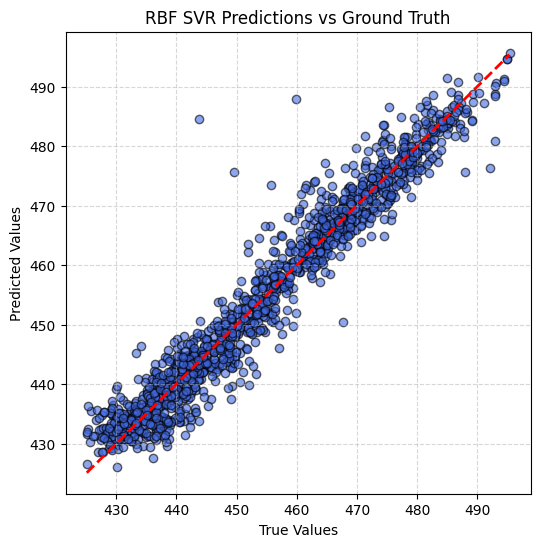

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot of true vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("RBF SVR Predictions vs Ground Truth")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()